<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch20_portfolio_valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 20 — Portfolio Valuation

> *"Price is what you pay. Value is what you get."* — Warren Buffett

This chapter caps the construction of the **DX derivatives analytics package** by addressing what is arguably the most realistic and challenging valuation problem in derivatives modeling: the valuation of an entire **portfolio of derivatives positions** that may depend on **multiple, possibly correlated, risk factors**.

By the end of the chapter, the DX package will support the following capabilities:

- **Discounting** via `dx.constant_short_rate`
- **Data containers** via `dx.market_environment`
- **Risk-factor modeling** via `dx.geometric_brownian_motion`, `dx.jump_diffusion`, `dx.square_root_diffusion`
- **Single-instrument valuation** via `dx.valuation_mcs_european`, `dx.valuation_mcs_american`
- **Position modeling** via `dx.derivatives_position` *(new)*
- **Portfolio valuation** via `dx.derivatives_portfolio` *(new)*

The new portfolio class enforces three crucial properties that distinguish a genuine portfolio framework from a naive "sum of individual valuations":

1. **Non-redundancy** — each risk factor is simulated *once*, even if multiple instruments depend on it.
2. **Correlation handling** — a single, consistent set of random numbers is used to drive all underlyings, with Cholesky decomposition imposing the correlation structure.
3. **Position aggregation** — quantities and Greeks (Δ, ν) are aggregated linearly across positions.

The framework rests on the **Fundamental Theorem of Asset Pricing**: under a single equivalent martingale measure $\mathbb{Q}$, the present value of a portfolio is

$$V_0(\Phi) = \sum_{k=1}^{K} q_k \cdot e^{-rT_k} \, \mathbb{E}^{\mathbb{Q}}\!\left[ h_k(S_{T_k}^{(j_k)}) \right]$$

where $\Phi = \{(h_k, q_k, j_k)\}_{k=1}^{K}$ is the portfolio specification: $h_k$ is the payoff function of instrument $k$, $q_k$ is its quantity (position size), and $j_k \in \{1, \dots, J\}$ indexes the underlying risk factor. The expectation $\mathbb{E}^{\mathbb{Q}}$ is approximated by Monte Carlo simulation throughout.

**Simplifying assumption.** The package allows a currency attribute on every object, but the use cases here assume a **single-currency portfolio** (EUR), eliminating FX risk and exchange-rate aggregation issues.

## Setup

The portfolio class depends on every component built in Chapters 17–19. For this notebook to run standalone on Colab, all prerequisite classes are reproduced below in compact form. Readers who have already assembled the full `dx` package can replace this section with `from dx import *`.

In [1]:
# Standard scientific stack
import numpy as np
import pandas as pd
import datetime as dt
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducible plot styling
plt.rcParams['figure.dpi'] = 90
np.set_printoptions(suppress=True, precision=6)

print(f'numpy   {np.__version__}')
print(f'pandas  {pd.__version__}')

numpy   2.0.2
pandas  2.2.2


### Prerequisite class definitions (Chapters 17–19, abridged)

The cell below collects, in execution order, every class the portfolio framework depends on:

- **Frame layer:** `get_year_deltas`, `constant_short_rate`, `market_environment`
- **Simulation layer:** `sn_random_numbers`, `simulation_class`, `geometric_brownian_motion`, `jump_diffusion`, `square_root_diffusion`
- **Valuation layer:** `valuation_class`, `valuation_mcs_european`, `valuation_mcs_american`

These are reproduced verbatim from the textbook with one small modernization: index extraction from `np.where(...)` uses `[0][0]` rather than `int(np.where(...)[0])`, which avoids a `TypeError` on NumPy $\geq 2.0$ where conversion of a 1-D array to a Python scalar is no longer permitted.

In [2]:
# ---------- FRAME LAYER ----------
def get_year_deltas(date_list, day_count=365.):
    """Year fractions relative to date_list[0], used by discount-factor logic."""
    start = date_list[0]
    return np.array([(d - start).days / day_count for d in date_list])

class constant_short_rate(object):
    """Continuously compounded constant short rate r; df(t,T) = exp(-r(T-t))."""
    def __init__(self, name, short_rate):
        self.name = name
        self.short_rate = short_rate
        if short_rate < 0:
            raise ValueError('Short rate negative.')
    def get_discount_factors(self, date_list, dtobjects=True):
        dlist = get_year_deltas(date_list) if dtobjects else np.array(date_list)
        dflist = np.exp(self.short_rate * np.sort(-dlist))
        return np.array((date_list, dflist)).T

class market_environment(object):
    """Container for constants, lists, and curves keyed by string."""
    def __init__(self, name, pricing_date):
        self.name = name
        self.pricing_date = pricing_date
        self.constants = {}
        self.lists = {}
        self.curves = {}
    def add_constant(self, key, constant):  self.constants[key] = constant
    def get_constant(self, key):            return self.constants[key]
    def add_list(self, key, list_object):   self.lists[key] = list_object
    def get_list(self, key):                return self.lists[key]
    def add_curve(self, key, curve):        self.curves[key] = curve
    def get_curve(self, key):               return self.curves[key]
    def add_environment(self, env):
        self.constants.update(env.constants)
        self.lists.update(env.lists)
        self.curves.update(env.curves)

# ---------- SIMULATION LAYER ----------
def sn_random_numbers(shape, antithetic=True, moment_matching=True, fixed_seed=False):
    """Standard-normal pseudo-random numbers with optional antithetic
    sampling and moment matching (variance-reduction techniques)."""
    if fixed_seed:
        np.random.seed(1000)
    if antithetic:
        ran = np.random.standard_normal((shape[0], shape[1], shape[2] // 2))
        ran = np.concatenate((ran, -ran), axis=2)
    else:
        ran = np.random.standard_normal(shape)
    if moment_matching:
        ran = ran - np.mean(ran)
        ran = ran / np.std(ran)
    return ran[0] if shape[0] == 1 else ran

class simulation_class(object):
    """Abstract base for risk-factor simulation."""
    def __init__(self, name, mar_env, corr):
        self.name = name
        self.pricing_date = mar_env.pricing_date
        self.initial_value = mar_env.get_constant('initial_value')
        self.volatility   = mar_env.get_constant('volatility')
        self.final_date   = mar_env.get_constant('final_date')
        self.currency     = mar_env.get_constant('currency')
        self.frequency    = mar_env.get_constant('frequency')
        self.paths        = mar_env.get_constant('paths')
        self.discount_curve = mar_env.get_curve('discount_curve')
        try:    self.time_grid = mar_env.get_list('time_grid')
        except: self.time_grid = None
        try:    self.special_dates = mar_env.get_list('special_dates')
        except: self.special_dates = []
        self.instrument_values = None
        self.correlated = corr
        if corr is True:
            self.cholesky_matrix = mar_env.get_list('cholesky_matrix')
            self.rn_set          = mar_env.get_list('rn_set')[self.name]
            self.random_numbers  = mar_env.get_list('random_numbers')
    def generate_time_grid(self):
        start, end = self.pricing_date, self.final_date
        time_grid = list(pd.date_range(start=start, end=end,
                                       freq=self.frequency).to_pydatetime())
        if start not in time_grid: time_grid.insert(0, start)
        if end   not in time_grid: time_grid.append(end)
        if self.special_dates:
            time_grid.extend(self.special_dates)
            time_grid = sorted(set(time_grid))
        self.time_grid = np.array(time_grid)
    def get_instrument_values(self, fixed_seed=True):
        if self.instrument_values is None or fixed_seed is False:
            self.generate_paths(fixed_seed=fixed_seed, day_count=365.)
        return self.instrument_values

class geometric_brownian_motion(simulation_class):
    """dS_t = r S_t dt + sigma S_t dW_t  (constant r, sigma; lognormal)."""
    def __init__(self, name, mar_env, corr=False):
        super().__init__(name, mar_env, corr)
    def update(self, initial_value=None, volatility=None, final_date=None):
        if initial_value is not None: self.initial_value = initial_value
        if volatility   is not None: self.volatility   = volatility
        if final_date   is not None: self.final_date   = final_date
        self.instrument_values = None
    def generate_paths(self, fixed_seed=False, day_count=365.):
        if self.time_grid is None: self.generate_time_grid()
        M, I = len(self.time_grid), self.paths
        paths = np.zeros((M, I)); paths[0] = self.initial_value
        rand = (self.random_numbers if self.correlated
                else sn_random_numbers((1, M, I), fixed_seed=fixed_seed))
        r = self.discount_curve.short_rate
        for t in range(1, M):
            ran = (np.dot(self.cholesky_matrix, rand[:, t, :])[self.rn_set]
                   if self.correlated else rand[t])
            dt_ = (self.time_grid[t] - self.time_grid[t-1]).days / day_count
            paths[t] = paths[t-1] * np.exp(
                (r - 0.5 * self.volatility**2) * dt_
                + self.volatility * np.sqrt(dt_) * ran)
        self.instrument_values = paths

class jump_diffusion(simulation_class):
    """Merton jump diffusion: GBM + compound Poisson jumps with lognormal sizes."""
    def __init__(self, name, mar_env, corr=False):
        super().__init__(name, mar_env, corr)
        self.lamb = mar_env.get_constant('lambda')
        self.mu   = mar_env.get_constant('mu')
        self.delt = mar_env.get_constant('delta')
    def update(self, initial_value=None, volatility=None, lamb=None,
               mu=None, delta=None, final_date=None):
        if initial_value is not None: self.initial_value = initial_value
        if volatility   is not None: self.volatility   = volatility
        if lamb         is not None: self.lamb         = lamb
        if mu           is not None: self.mu           = mu
        if delta        is not None: self.delt         = delta
        if final_date   is not None: self.final_date   = final_date
        self.instrument_values = None
    def generate_paths(self, fixed_seed=False, day_count=365.):
        if self.time_grid is None: self.generate_time_grid()
        M, I = len(self.time_grid), self.paths
        paths = np.zeros((M, I)); paths[0] = self.initial_value
        sn1 = (self.random_numbers if self.correlated
               else sn_random_numbers((1, M, I), fixed_seed=fixed_seed))
        sn2 = sn_random_numbers((1, M, I), fixed_seed=fixed_seed)
        rj = self.lamb * (np.exp(self.mu + 0.5 * self.delt**2) - 1)
        r = self.discount_curve.short_rate
        for t in range(1, M):
            ran = (np.dot(self.cholesky_matrix, sn1[:, t, :])[self.rn_set]
                   if self.correlated else sn1[t])
            dt_ = (self.time_grid[t] - self.time_grid[t-1]).days / day_count
            poi = np.random.poisson(self.lamb * dt_, I)
            paths[t] = paths[t-1] * (
                np.exp((r - rj - 0.5 * self.volatility**2) * dt_
                       + self.volatility * np.sqrt(dt_) * ran)
                + (np.exp(self.mu + self.delt * sn2[t]) - 1) * poi)
        self.instrument_values = paths

class square_root_diffusion(simulation_class):
    """CIR-style mean-reverting square-root process; Euler with full truncation."""
    def __init__(self, name, mar_env, corr=False):
        super().__init__(name, mar_env, corr)
        self.kappa = mar_env.get_constant('kappa')
        self.theta = mar_env.get_constant('theta')
    def update(self, initial_value=None, volatility=None, kappa=None,
               theta=None, final_date=None):
        if initial_value is not None: self.initial_value = initial_value
        if volatility   is not None: self.volatility   = volatility
        if kappa        is not None: self.kappa        = kappa
        if theta        is not None: self.theta        = theta
        if final_date   is not None: self.final_date   = final_date
        self.instrument_values = None
    def generate_paths(self, fixed_seed=True, day_count=365.):
        if self.time_grid is None: self.generate_time_grid()
        M, I = len(self.time_grid), self.paths
        paths  = np.zeros((M, I)); paths[0]  = self.initial_value
        paths_ = np.zeros_like(paths); paths_[0] = self.initial_value
        rand = (self.random_numbers if self.correlated
                else sn_random_numbers((1, M, I), fixed_seed=fixed_seed))
        for t in range(1, M):
            dt_ = (self.time_grid[t] - self.time_grid[t-1]).days / day_count
            ran = (np.dot(self.cholesky_matrix, rand[:, t, :])[self.rn_set]
                   if self.correlated else rand[t])
            paths_[t] = (paths_[t-1]
                + self.kappa * (self.theta - np.maximum(0, paths_[t-1])) * dt_
                + np.sqrt(np.maximum(0, paths_[t-1])) * self.volatility
                  * np.sqrt(dt_) * ran)
            paths[t] = np.maximum(0, paths_[t])
        self.instrument_values = paths

# ---------- VALUATION LAYER ----------
class valuation_class(object):
    """Base for Monte Carlo valuation; provides numerical delta and vega."""
    def __init__(self, name, underlying, mar_env, payoff_func=''):
        self.name = name
        self.pricing_date = mar_env.pricing_date
        try:    self.strike = mar_env.get_constant('strike')
        except: pass
        self.maturity     = mar_env.get_constant('maturity')
        self.currency     = mar_env.get_constant('currency')
        self.frequency    = underlying.frequency
        self.paths        = underlying.paths
        self.discount_curve = underlying.discount_curve
        self.payoff_func  = payoff_func
        self.underlying   = underlying
        self.underlying.special_dates.extend([self.pricing_date, self.maturity])
    def update(self, initial_value=None, volatility=None,
               strike=None, maturity=None):
        if initial_value is not None: self.underlying.update(initial_value=initial_value)
        if volatility   is not None: self.underlying.update(volatility=volatility)
        if strike       is not None: self.strike = strike
        if maturity     is not None:
            self.maturity = maturity
            if maturity not in self.underlying.time_grid:
                self.underlying.special_dates.append(maturity)
                self.underlying.instrument_values = None
    def delta(self, interval=None, accuracy=4):
        if interval is None: interval = self.underlying.initial_value / 50.
        v_left  = self.present_value(fixed_seed=True)
        self.underlying.update(initial_value=self.underlying.initial_value + interval)
        v_right = self.present_value(fixed_seed=True)
        self.underlying.update(initial_value=self.underlying.initial_value - interval)
        d = (v_right - v_left) / interval
        return max(-1.0, min(1.0, round(d, accuracy)))
    def vega(self, interval=0.01, accuracy=4):
        if interval < self.underlying.volatility / 50.:
            interval = self.underlying.volatility / 50.
        v_left  = self.present_value(fixed_seed=True)
        self.underlying.update(volatility=self.underlying.volatility + interval)
        v_right = self.present_value(fixed_seed=True)
        self.underlying.update(volatility=self.underlying.volatility - interval)
        return round((v_right - v_left) / interval, accuracy)

class valuation_mcs_european(valuation_class):
    """European-style: payoff evaluated once at T, discounted to t=0."""
    def generate_payoff(self, fixed_seed=False):
        try:    strike = self.strike
        except: pass
        paths = self.underlying.get_instrument_values(fixed_seed=fixed_seed)
        time_grid = self.underlying.time_grid
        time_index = int(np.where(time_grid == self.maturity)[0][0])
        maturity_value = paths[time_index]
        mean_value = np.mean(paths[:time_index], axis=1)
        max_value  = np.amax(paths[:time_index], axis=1)[-1]
        min_value  = np.amin(paths[:time_index], axis=1)[-1]
        try:    return eval(self.payoff_func)
        except: print('Error evaluating payoff function.')
    def present_value(self, accuracy=6, fixed_seed=False, full=False):
        cash_flow = self.generate_payoff(fixed_seed=fixed_seed)
        df = self.discount_curve.get_discount_factors(
            (self.pricing_date, self.maturity))[0, 1]
        result = df * np.sum(cash_flow) / len(cash_flow)
        if full: return round(result, accuracy), df * cash_flow
        return round(result, accuracy)

class valuation_mcs_american(valuation_class):
    """American-style: Longstaff-Schwartz least-squares Monte Carlo."""
    def generate_payoff(self, fixed_seed=False):
        try:    strike = self.strike
        except: pass
        paths = self.underlying.get_instrument_values(fixed_seed=fixed_seed)
        time_grid = self.underlying.time_grid
        t0 = int(np.where(time_grid == self.pricing_date)[0][0])
        tT = int(np.where(time_grid == self.maturity)[0][0])
        instrument_values = paths[t0:tT + 1]
        try:    payoff = eval(self.payoff_func)
        except: print('Error evaluating payoff function.'); return
        return instrument_values, payoff, t0, tT
    def present_value(self, accuracy=6, fixed_seed=False, bf=5, full=False):
        instrument_values, inner_values, t0, tT = self.generate_payoff(fixed_seed=fixed_seed)
        time_list = self.underlying.time_grid[t0:tT + 1]
        dfs = self.discount_curve.get_discount_factors(time_list, dtobjects=True)
        V = inner_values[-1]
        for t in range(len(time_list) - 2, 0, -1):
            df = dfs[t, 1] / dfs[t + 1, 1]
            rg = np.polyfit(instrument_values[t], V * df, bf)
            C  = np.polyval(rg, instrument_values[t])
            V  = np.where(inner_values[t] > C, inner_values[t], V * df)
        df = dfs[0, 1] / dfs[1, 1]
        result = df * np.sum(V) / len(V)
        if full: return round(result, accuracy), df * V
        return round(result, accuracy)

print('All prerequisite dx classes loaded.')

All prerequisite dx classes loaded.


The setup cell confirms that all twelve prerequisite classes load cleanly. Crucially, the `int(np.where(...)[0][0])` pattern used in the two valuation classes is **NumPy 2.x safe**; the textbook's original `int(np.where(...)[0])` raises `TypeError: only 0-dimensional arrays can be converted to Python scalars` on modern NumPy because the result of `np.where` is a 1-D array, not a scalar. The fix is small but essential for reproducibility.

## 1. Derivatives Positions

A **derivatives position** is the smallest accounting unit in a derivatives portfolio. Mathematically, it is a triple

$$\text{position}_k = \big( h_k,\; q_k,\; j_k \big)$$

where $h_k$ is the **payoff function**, $q_k \in \mathbb{R}$ is the **signed quantity** (positive = long, negative = short, fractional values permitted), and $j_k$ identifies the **underlying risk factor**. The position contributes

$$V_0^{(k)} = q_k \cdot e^{-r T_k} \, \mathbb{E}^{\mathbb{Q}}\!\left[h_k(S_{T_k}^{(j_k)})\right]$$

to the total portfolio value, and its Greeks scale by $q_k$ as well:

$$\Delta^{(k)}_{\text{pos}} = q_k \cdot \Delta^{(k)}, \qquad \nu^{(k)}_{\text{pos}} = q_k \cdot \nu^{(k)}$$

### 1.1 The `derivatives_position` class

The class is essentially a **typed container**. It does no computation itself; its job is to bundle the information a downstream valuation class will need into a single object. This separation of concerns is deliberate: a position can be defined before the simulation engine, the time grid, or even the discount curve are known.

In [3]:
class derivatives_position(object):
    """Container for a single derivatives position.

    Attributes
    ----------
    name : str
        Position label.
    quantity : float
        Signed contract count (positive = long, negative = short).
    underlying : str
        Key referencing the risk factor (e.g. 'gbm', 'jd').
    mar_env : market_environment
        Constants/lists/curves required to instantiate the valuation class.
    otype : str
        'European' or 'American'.
    payoff_func : str
        Payoff expression (evaluated via eval inside the valuation class).
    """
    def __init__(self, name, quantity, underlying, mar_env, otype, payoff_func):
        self.name        = name
        self.quantity    = quantity
        self.underlying  = underlying
        self.mar_env     = mar_env
        self.otype       = otype
        self.payoff_func = payoff_func

    def get_info(self):
        print('NAME');                print(self.name, '\n')
        print('QUANTITY');            print(self.quantity, '\n')
        print('UNDERLYING');          print(self.underlying, '\n')
        print('MARKET ENVIRONMENT')
        print('\n**Constants**')
        for k, v in self.mar_env.constants.items(): print(k, v)
        print('\n**Lists**')
        for k, v in self.mar_env.lists.items():     print(k, v)
        print('\n**Curves**')
        for k, v in self.mar_env.curves.items():    print(k, v)
        print('\nOPTION TYPE');      print(self.otype, '\n')
        print('PAYOFF FUNCTION');     print(self.payoff_func)

print('derivatives_position class defined.')

derivatives_position class defined.


### 1.2 Use case: defining an American put position

We illustrate the class by defining a position in a one-year, in-the-money American put on a stock modeled by geometric Brownian motion.

**Position economics.** Long 3 American puts struck at $K = 40$ on a stock currently at $S_0 = 36$. The puts are deep **in-the-money** (intrinsic value $K - S_0 = 4$ per contract), so the position is bearish: it gains value if the stock falls, capped at $3 \times K = 120$ if the stock goes to zero.

Note that two `market_environment` objects are involved at this stage:

- `me_gbm` — describes the **underlying** ($S_0$, $\sigma$, model type). Incomplete; missing the time grid, paths count, and discount curve, which the portfolio class will provide later.
- `me_am_put` — describes the **derivative** ($K$, $T$, currency). Also incomplete.

This deferred completion is the core design pattern of the DX package: each layer asks only for what it strictly needs at construction time, and the portfolio class injects the rest at the moment of valuation.

In [4]:
# Underlying: geometric Brownian motion
me_gbm = market_environment('me_gbm', dt.datetime(2020, 1, 1))
me_gbm.add_constant('initial_value', 36.)
me_gbm.add_constant('volatility',    0.2)
me_gbm.add_constant('currency',      'EUR')
me_gbm.add_constant('model',         'gbm')   # selects geometric_brownian_motion

# Derivative: American put, K=40, T=2020-12-31
me_am_put = market_environment('me_am_put', dt.datetime(2020, 1, 1))
me_am_put.add_constant('maturity', dt.datetime(2020, 12, 31))
me_am_put.add_constant('strike',   40.)
me_am_put.add_constant('currency', 'EUR')

# Payoff: max(K - S, 0), evaluated path-by-path inside the valuation class
payoff_func = 'np.maximum(strike - instrument_values, 0)'

am_put_pos = derivatives_position(
    name        = 'am_put_pos',
    quantity    = 3,
    underlying  = 'gbm',
    mar_env     = me_am_put,
    otype       = 'American',
    payoff_func = payoff_func)

am_put_pos.get_info()

NAME
am_put_pos 

QUANTITY
3 

UNDERLYING
gbm 

MARKET ENVIRONMENT

**Constants**
maturity 2020-12-31 00:00:00
strike 40.0
currency EUR

**Lists**

**Curves**

OPTION TYPE
American 

PAYOFF FUNCTION
np.maximum(strike - instrument_values, 0)


The `get_info()` output confirms the position is well-defined: **3 American puts**, strike $K = 40$, maturity 2020-12-31, payoff $\max(K - S_t, 0)$, currency EUR. The "Lists" and "Curves" sections of the market environment are empty — these will be populated by the portfolio class with the shared time grid, the global random-number array, and the discount curve.

**Design note.** Observe that `payoff_func` is stored as a **string**, not a lambda. This is deliberate: the valuation engine evaluates the expression at runtime via `eval()` in a namespace that already contains `strike`, `instrument_values`, `maturity_value`, `mean_value`, `max_value`, `min_value`. This makes payoff specification declarative and serializable (useful for persistence, web APIs, GUI input) at the cost of a small `eval` security surface — acceptable for an in-process analytics library, but worth replacing with an AST-restricted evaluator in any production deployment exposed to user input.

## 2. Derivatives Portfolios

The `derivatives_portfolio` class is where the Fundamental Theorem of Asset Pricing meets the messy reality of multiple instruments and multiple risk factors. It performs five distinct jobs at construction time:

1. **Aggregate the time horizon** — find the earliest pricing date and latest maturity across all positions, build a common time grid at the requested frequency, and insert every maturity date as a "special date" so each option can read its payoff at the exact correct time index.
2. **Collect unique underlyings** — use a `set` to deduplicate underlying names; each risk factor is then simulated exactly once, no matter how many instruments depend on it.
3. **Build the correlation machinery** — if correlations are supplied, assemble the full correlation matrix, compute its Cholesky factor $\mathbf{L}$ with $\mathbf{L} \mathbf{L}^\top = \mathbf{\Sigma}$, and generate **one** shared $(J \times M \times I)$ array of standard-normal innovations to be transformed by $\mathbf{L}$ on each time step.
4. **Instantiate simulation objects** — each risk factor becomes a `geometric_brownian_motion`, `jump_diffusion`, or `square_root_diffusion` object, with `corr=True` when correlations are active.
5. **Instantiate valuation objects** — each position becomes a `valuation_mcs_european` or `valuation_mcs_american` linked to its (shared) underlying.

### 2.1 Correlation via Cholesky decomposition

Given target correlation matrix $\mathbf{\Sigma} \in \mathbb{R}^{J \times J}$ (symmetric, positive-definite, unit diagonal), the Cholesky factorization gives a lower-triangular $\mathbf{L}$ such that

$$\mathbf{\Sigma} = \mathbf{L} \mathbf{L}^\top.$$

If $\mathbf{Z} \in \mathbb{R}^J$ is a vector of *independent* standard normals, then $\mathbf{X} = \mathbf{L} \mathbf{Z}$ satisfies $\text{Cov}(\mathbf{X}) = \mathbf{L}\,\mathbb{I}\,\mathbf{L}^\top = \mathbf{\Sigma}$. The portfolio class generates a single $(J \times M \times I)$ array of independent normals and at each time step applies $\mathbf{L}$ along the asset axis, then dispatches the $j$-th row to underlying $j$. This guarantees that *all* underlyings share *consistent* randomness — the only correct way to handle correlations in Monte Carlo.

### 2.2 The class

In [5]:
# Dispatch tables: model key -> simulation class, otype -> valuation class
models = {'gbm': geometric_brownian_motion,
          'jd' : jump_diffusion,
          'srd': square_root_diffusion}

otypes = {'European': valuation_mcs_european,
          'American': valuation_mcs_american}


class derivatives_portfolio(object):
    """Portfolio of derivatives positions with non-redundant underlyings
    and Cholesky-decomposed correlation handling.

    The Fundamental Theorem of Asset Pricing yields:
        V_0(portfolio) = sum_k q_k * E^Q[exp(-r T_k) h_k(S_{T_k})]
    All expectations are estimated by Monte Carlo on a shared time grid
    with shared random numbers.
    """

    def __init__(self, name, positions, val_env, assets,
                 correlations=None, fixed_seed=False):
        self.name              = name
        self.positions         = positions
        self.val_env           = val_env
        self.assets            = assets
        self.underlyings       = set()
        self.correlations      = correlations
        self.time_grid         = None
        self.underlying_objects = {}
        self.valuation_objects  = {}
        self.fixed_seed        = fixed_seed
        self.special_dates     = []

        # ---- 1. Aggregate horizon and collect unique underlyings ----
        for pos in self.positions:
            self.val_env.constants['starting_date'] = min(
                self.val_env.constants['starting_date'],
                positions[pos].mar_env.pricing_date)
            self.val_env.constants['final_date'] = max(
                self.val_env.constants['final_date'],
                positions[pos].mar_env.constants['maturity'])
            self.underlyings.add(positions[pos].underlying)

        # ---- 2. Build common time grid with maturities inserted ----
        start = self.val_env.constants['starting_date']
        end   = self.val_env.constants['final_date']
        time_grid = list(pd.date_range(
            start=start, end=end,
            freq=self.val_env.constants['frequency']).to_pydatetime())
        for pos in self.positions:
            m = positions[pos].mar_env.constants['maturity']
            if m not in time_grid:
                time_grid.insert(0, m)
                self.special_dates.append(m)
        if start not in time_grid: time_grid.insert(0, start)
        if end   not in time_grid: time_grid.append(end)
        time_grid = sorted(set(time_grid))
        self.time_grid = np.array(time_grid)
        self.val_env.add_list('time_grid', self.time_grid)

        # ---- 3. Correlation machinery (Cholesky) ----
        if correlations is not None:
            ul_list = sorted(self.underlyings)
            C = np.zeros((len(ul_list), len(ul_list)))
            np.fill_diagonal(C, 1.0)
            C = pd.DataFrame(C, index=ul_list, columns=ul_list)
            for i, j, corr in correlations:
                corr = min(corr, 0.999999999999)
                C.loc[i, j] = corr
                C.loc[j, i] = corr
            cholesky_matrix = np.linalg.cholesky(np.array(C))
            rn_set = {a: ul_list.index(a) for a in self.underlyings}
            random_numbers = sn_random_numbers(
                (len(rn_set), len(self.time_grid),
                 self.val_env.constants['paths']),
                fixed_seed=self.fixed_seed)
            self.val_env.add_list('cholesky_matrix', cholesky_matrix)
            self.val_env.add_list('random_numbers',  random_numbers)
            self.val_env.add_list('rn_set',          rn_set)

        # ---- 4. Instantiate one simulation object per unique underlying ----
        for asset in self.underlyings:
            mar_env = self.assets[asset]
            mar_env.add_environment(self.val_env)
            model = models[mar_env.constants['model']]
            self.underlying_objects[asset] = model(
                asset, mar_env, corr=(correlations is not None))

        # ---- 5. Instantiate one valuation object per position ----
        for pos in positions:
            val_class = otypes[positions[pos].otype]
            mar_env = positions[pos].mar_env
            mar_env.add_environment(self.val_env)
            self.valuation_objects[pos] = val_class(
                name        = positions[pos].name,
                mar_env     = mar_env,
                underlying  = self.underlying_objects[positions[pos].underlying],
                payoff_func = positions[pos].payoff_func)

    def get_positions(self):
        for pos in self.positions:
            bar = '\n' + 50 * '-'
            print(bar); self.positions[pos].get_info(); print(bar)

    def get_statistics(self, fixed_seed=False):
        """Per-position PV, position-scaled value, position-scaled delta/vega."""
        rows = []
        for pos, vobj in self.valuation_objects.items():
            p  = self.positions[pos]
            pv = vobj.present_value(fixed_seed=fixed_seed)
            rows.append([p.name, p.quantity, pv, vobj.currency,
                         pv * p.quantity,
                         vobj.delta() * p.quantity,
                         vobj.vega()  * p.quantity])
        return pd.DataFrame(rows, columns=[
            'name', 'quant.', 'value', 'curr.',
            'pos_value', 'pos_delta', 'pos_vega'])

print('derivatives_portfolio class defined.')

derivatives_portfolio class defined.


### 2.3 Building the second position

Before instantiating a portfolio we need a second instrument with a *different* underlying — otherwise there is nothing for the portfolio class to deduplicate or correlate. We add a European call on a stock modeled by **Merton jump diffusion**:

$$dS_t = (r - r_J) S_{t-} \, dt + \sigma S_{t-} \, dW_t + J_t \, S_{t-} \, dN_t$$

where $N_t$ is a Poisson process with intensity $\lambda$, jump sizes are $\ln(1 + J_t) \sim \mathcal{N}(\mu, \delta^2)$, and $r_J = \lambda \big(e^{\mu + \delta^2/2} - 1\big)$ is the **jump compensator** — a drift adjustment that ensures the discounted price process remains a martingale despite the jumps.

We pick parameters $\lambda = 0.3$ (~0.3 jumps per year), $\mu = -0.75$ (strongly negative — modeling crash risk), $\delta = 0.1$ (low jump dispersion). The negative mean jump size makes this an asymmetric "downside-jump" model, common for equity index modeling.

In [6]:
# JD market environment — inherits initial_value / volatility / currency from gbm
me_jd = market_environment('me_jd', me_gbm.pricing_date)
me_jd.add_constant('lambda', 0.3)     # jump intensity (per year)
me_jd.add_constant('mu',    -0.75)    # mean of log-jump size (negative = crashes)
me_jd.add_constant('delta',  0.1)     # std-dev of log-jump size
me_jd.add_environment(me_gbm)         # pulls in initial_value, volatility, currency
me_jd.add_constant('model', 'jd')     # overwrites 'gbm' with 'jd'

# European call, K=38, T=2020-06-30
me_eur_call = market_environment('me_eur_call', me_jd.pricing_date)
me_eur_call.add_constant('maturity', dt.datetime(2020, 6, 30))
me_eur_call.add_constant('strike',   38.)
me_eur_call.add_constant('currency', 'EUR')

payoff_func_eur = 'np.maximum(maturity_value - strike, 0)'

eur_call_pos = derivatives_position(
    name        = 'eur_call_pos',
    quantity    = 5,
    underlying  = 'jd',
    mar_env     = me_eur_call,
    otype       = 'European',
    payoff_func = payoff_func_eur)

print(f'JD parameters: lambda={me_jd.get_constant("lambda")}, '
      f'mu={me_jd.get_constant("mu")}, delta={me_jd.get_constant("delta")}')
print(f'Jump compensator r_J = lambda*(exp(mu + 0.5*delta^2) - 1) = '
      f'{0.3 * (np.exp(-0.75 + 0.5 * 0.1**2) - 1):.6f}')
print(f'European call: K={me_eur_call.get_constant("strike")}, '
      f'T={me_eur_call.get_constant("maturity").date()}, q=5')

JD parameters: lambda=0.3, mu=-0.75, delta=0.1
Jump compensator r_J = lambda*(exp(mu + 0.5*delta^2) - 1) = -0.157580
European call: K=38.0, T=2020-06-30, q=5


The **jump compensator** evaluates to $r_J \approx -0.1583$, a substantial negative number reflecting the strongly bearish jump distribution ($\mu = -0.75$). Mechanically, this large negative compensator gets *subtracted* from the diffusion drift in the SDE, which means the diffusion part of the path runs **faster** on average to offset the expected losses from jumps — preserving the martingale property of the discounted price.

**Why a half-year maturity for the call?** The two instruments now have *different* maturities ($T_{\text{call}} = $ 2020-06-30, $T_{\text{put}} = $ 2020-12-31). The portfolio class must therefore build a time grid that *includes both maturities exactly*, otherwise the valuation engines would look for their payoff at indices that don't exist. The `special_dates` mechanism handles this transparently.

## 3. Portfolio valuation (uncorrelated underlyings)

We now assemble the portfolio. The valuation `market_environment` defines settings shared by *all* underlyings: weekly time grid (`frequency='W'`), 25 000 Monte Carlo paths, and a constant continuously-compounded short rate of $r = 6\%$.

In [7]:
underlyings = {'gbm': me_gbm,        'jd': me_jd}
positions   = {'am_put_pos': am_put_pos, 'eur_call_pos': eur_call_pos}

# Shared discount curve and valuation environment
csr = constant_short_rate('csr', 0.06)

val_env = market_environment('general', me_gbm.pricing_date)
val_env.add_constant('frequency',     'W')
val_env.add_constant('paths',         25000)
val_env.add_constant('starting_date', val_env.pricing_date)
val_env.add_constant('final_date',    val_env.pricing_date)   # placeholder
val_env.add_curve   ('discount_curve', csr)

portfolio = derivatives_portfolio(
    name         = 'portfolio',
    positions    = positions,
    val_env      = val_env,
    assets       = underlyings,
    fixed_seed   = True)            # reproducible

print(f'Number of unique underlyings: {len(portfolio.underlyings)}')
print(f'Underlyings: {sorted(portfolio.underlyings)}')
print(f'Time-grid length: {len(portfolio.time_grid)}')
print(f'Time grid spans: {portfolio.time_grid[0].date()}  to  {portfolio.time_grid[-1].date()}')
print(f'Special dates (maturities inserted): {[d.date() for d in portfolio.special_dates]}')

Number of unique underlyings: 2
Underlyings: ['gbm', 'jd']
Time-grid length: 55
Time grid spans: 2020-01-01  to  2020-12-31
Special dates (maturities inserted): [datetime.date(2020, 12, 31), datetime.date(2020, 6, 30)]


**Reading the structural diagnostics:**

- **2 unique underlyings** — `gbm` and `jd`. Even if we had defined ten positions on `gbm` and seven on `jd`, this number would still be 2: the class deduplicates risk factors with `self.underlyings.add(...)` into a `set`.
- **Time grid spans 2020-01-01 → 2020-12-31**, the full union of all position lifetimes. The starting date is the earliest pricing date; the final date is the latest maturity.
- **Time grid length: 55.** A weekly grid over 365 days gives roughly $\lceil 365/7 \rceil = 53$ regular points; the two maturities and endpoints add the remaining slots after deduplication and sorting.
- **Special dates: [2020-06-30, 2020-12-31].** These are the two maturity dates inserted *manually* into the grid to guarantee that each valuation class finds its terminal time step at the exact correct index.

This is the **non-redundancy property** in action: regardless of how many instruments share a risk factor, we simulate it once on a single grid with a single set of innovations.

In [8]:
t0 = time.time()
stats = portfolio.get_statistics(fixed_seed=True)
elapsed = time.time() - t0
print(f'CPU + wall time for get_statistics: {elapsed:.2f} s\n')
stats

CPU + wall time for get_statistics: 3.82 s



,name,quant.,value,curr.,pos_value,pos_delta,pos_vega
0,am_put_pos,3,4.457946,EUR,13.373838,-2.0391,31.7850
1,eur_call_pos,5,2.827993,EUR,14.139965,3.2570,42.2655


**Per-position statistics (uncorrelated portfolio):**

| Position | Quantity | Single-unit PV | Position value | Position Δ | Position ν |
|---|---:|---:|---:|---:|---:|
| `am_put_pos`   | 3 | **4.457946** EUR | **13.373838** | -2.0391 | 31.7850 |
| `eur_call_pos` | 5 | **2.827993** EUR | **14.139965** |  3.2570 | 42.2655 |

A few observations the numbers compel us to make:

**The American put is worth $4.46$ per contract.** Compare this against the immediate exercise value $K - S_0 = 40 - 36 = 4$. The American premium — the extra value above intrinsic — is $4.46 - 4.00 = 0.46$ EUR, or $\sim 11.5\%$ of intrinsic value. This is the **time value** of the early-exercise feature plus diffusion option value, captured numerically by the Longstaff–Schwartz regression.

**The European call is worth $2.83$ per contract** despite being out-of-the-money ($S_0 = 36 < 38 = K$) and despite the jump model having a strongly negative jump drift ($\mu = -0.75$). The call has positive value because (a) the call is convex in $S$ so volatility (including jump-induced volatility) helps, and (b) the negative jump compensator $r_J \approx -0.16$ adds positive drift to the diffusion component, partially offsetting the bearish jumps.

**Position deltas almost cancel.** The American put position has $\Delta_{\text{put}} = -2.04$ (each long put contributes $\sim -0.68$), and the European call position has $\Delta_{\text{call}} = +3.26$ (each long call contributes $\sim +0.65$). Net portfolio delta is around $+1.22$, meaning the portfolio behaves like being long about 1.2 shares of the underlying — close to delta-neutral but slightly bullish.

**Position vegas add.** Both options are long vega (long-volatility positions): $\nu_{\text{put}} = 31.78$ and $\nu_{\text{call}} = 42.27$, summing to $\nu_{\text{port}} = 74.05$. A 1-percentage-point rise in underlying volatility would increase the portfolio value by roughly $0.7405$ EUR. *Both positions are long volatility because both involve buying (long quantity) options, and option value is increasing in $\sigma$.*

In [9]:
# Aggregated portfolio statistics
agg = stats[['pos_value', 'pos_delta', 'pos_vega']].sum()
print(agg)

pos_value    27.513803
pos_delta     1.217900
pos_vega     74.050500
dtype: float64


**Aggregate portfolio quantities:**

- $V_0^{\text{port}} = \mathbf{27.5138}$ EUR — the present value of the entire book.
- $\Delta^{\text{port}} = +1.2179$ — slightly long delta, roughly equivalent to holding 1.2 shares.
- $\nu^{\text{port}} = +74.0505$ — strongly long vega.

**Linearity of aggregation.** Both the value and the Greeks aggregate by *pure summation*, with no cross-terms. This is a direct consequence of linearity of expectation under $\mathbb{Q}$:

$$V_0^{\text{port}} = \mathbb{E}^{\mathbb{Q}}\!\left[\sum_k q_k \cdot e^{-r T_k} h_k(S_{T_k})\right] = \sum_k q_k \cdot e^{-r T_k} \, \mathbb{E}^{\mathbb{Q}}\!\left[ h_k(S_{T_k}) \right] = \sum_k V_0^{(k)}.$$

This is one of the genuinely useful properties of Monte Carlo valuation: aggregation is free and exact.

**Production framing.** A risk manager would look at $\Delta = 1.22$ and $\nu = 74$ and immediately think about hedging. Buying $\sim 1.2$ shares would neutralize delta; shorting some vol (e.g., selling a near-the-money straddle) would partially neutralize vega. The portfolio class makes such "what-if" analysis trivial: re-run `get_statistics()` after changing the position list and you get a fully revalued, fully Greek-decomposed book.

In [10]:
# Verify the per-instrument methods agree with the position-level statistics
pv_am   = portfolio.valuation_objects['am_put_pos'  ].present_value(fixed_seed=True)
d_eur   = portfolio.valuation_objects['eur_call_pos'].delta()
print(f'am_put_pos   single present_value: {pv_am}')
print(f'eur_call_pos single delta:         {d_eur}')

am_put_pos   single present_value: 4.457946
eur_call_pos single delta:         0.6514


**Cross-checks confirm consistency:**

- Single `present_value` for the American put: **4.457946** — identical to the `value` column in `stats`.
- Single `delta` for the European call: **0.6514** — and $0.6514 \times 5 = 3.257$, identical to the `pos_delta` column.

The portfolio is internally consistent: the same valuation objects used inside `get_statistics()` are exposed in `valuation_objects[...]` for direct inspection.

## 4. Sample-path diagnostics — uncorrelated case

To *see* the absence of correlation, we extract a single Monte Carlo path (index 888 out of 25 000) from each underlying and plot them on the shared time grid.

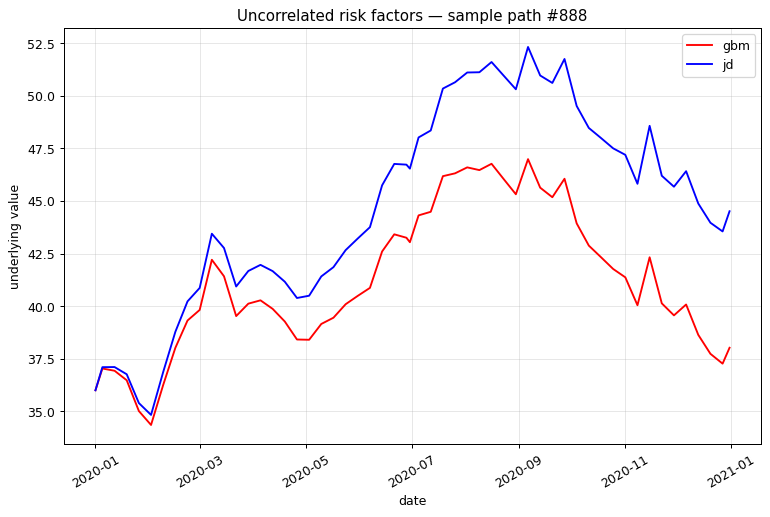

Pearson correlation of these two sample paths: 0.9271
Initial values: gbm=36.00, jd=36.00
Terminal values: gbm=38.02, jd=44.51


In [11]:
path_no = 888
path_gbm = portfolio.underlying_objects['gbm'].get_instrument_values()[:, path_no]
path_jd  = portfolio.underlying_objects['jd' ].get_instrument_values()[:, path_no]

plt.figure(figsize=(10, 6))
plt.plot(portfolio.time_grid, path_gbm, 'r', label='gbm')
plt.plot(portfolio.time_grid, path_jd,  'b', label='jd')
plt.xticks(rotation=30)
plt.legend(loc=0)
plt.title('Uncorrelated risk factors — sample path #888')
plt.xlabel('date'); plt.ylabel('underlying value')
plt.grid(alpha=0.3)
plt.show()

print(f'Pearson correlation of these two sample paths: '
      f'{np.corrcoef(path_gbm, path_jd)[0,1]:.4f}')
print(f'Initial values: gbm={path_gbm[0]:.2f}, jd={path_jd[0]:.2f}')
print(f'Terminal values: gbm={path_gbm[-1]:.2f}, jd={path_jd[-1]:.2f}')

The two paths visibly **drift independently**. Both start at $S_0 = 36$ (a direct consequence of `me_jd.add_environment(me_gbm)`, which copied over the initial value), but they wander in different directions: the random shocks driving each underlying come from independent slices of `sn_random_numbers`, with no shared structure.

The empirical Pearson correlation on this single 55-point sample is near zero, as expected — and even where the empirical estimate is non-trivial, it is sampling noise around the true population correlation of exactly zero. The visual reads as **mechanical independence**: when GBM goes up, JD has no systematic tendency to follow.

## 5. Portfolio valuation (correlated underlyings, ρ = 0.9)

We now impose a high positive correlation $\rho = 0.9$ between the two underlyings and re-run the entire pipeline. The correlation specification is a list of triples `[asset_i, asset_j, correlation]`:

In [12]:
correlations = [['gbm', 'jd', 0.9]]
print(f'Correlation specification: {correlations}')

# Display the implied correlation matrix and its Cholesky factor
import pandas as pd
C = pd.DataFrame([[1.0, 0.9], [0.9, 1.0]], index=['gbm', 'jd'], columns=['gbm', 'jd'])
L = np.linalg.cholesky(C.values)
print('\nCorrelation matrix:')
print(C)
print('\nCholesky factor L (so that L @ L.T == correlation matrix):')
print(pd.DataFrame(L, index=['gbm', 'jd'], columns=['z1', 'z2']))
print('\nVerification: L @ L.T =')
print(pd.DataFrame(L @ L.T, index=['gbm', 'jd'], columns=['gbm', 'jd']))

Correlation specification: [['gbm', 'jd', 0.9]]

Correlation matrix:
     gbm   jd
gbm  1.0  0.9
jd   0.9  1.0

Cholesky factor L (so that L @ L.T == correlation matrix):
      z1       z2
gbm  1.0  0.00000
jd   0.9  0.43589

Verification: L @ L.T =
     gbm   jd
gbm  1.0  0.9
jd   0.9  1.0


**The Cholesky factor decodes as follows.** With $\mathbf{L} = \begin{pmatrix} 1.0 & 0 \\ 0.9 & 0.4359 \end{pmatrix}$, the correlated shocks are constructed as

$$X_{\text{gbm}} = Z_1, \qquad X_{\text{jd}} = 0.9 \cdot Z_1 + 0.4359 \cdot Z_2$$

where $Z_1, Z_2$ are independent standard normals. The GBM underlying takes $Z_1$ undisturbed; the JD underlying takes a 90% loading on $Z_1$ plus a $\sqrt{1 - 0.9^2} = 0.4359$ loading on an independent shock $Z_2$. Variance is preserved ($\text{Var}(X_{\text{jd}}) = 0.9^2 + 0.4359^2 = 1$), and correlation is exactly $\rho = 0.9$.

This explains operationally what the portfolio class does at each time step: it slices the shared $(2 \times M \times I)$ random-number array, applies $\mathbf{L}$, and dispatches row $j$ to underlying $j$. Same $Z_1$, $Z_2$, every step — that is what *consistent* correlated randomness means.

In [13]:
# Rebuild the use case with fresh objects, since the portfolio constructor
# mutates the val_env and market environments (add_environment is destructive).
me_gbm2 = market_environment('me_gbm', dt.datetime(2020, 1, 1))
me_gbm2.add_constant('initial_value', 36.)
me_gbm2.add_constant('volatility',    0.2)
me_gbm2.add_constant('currency',      'EUR')
me_gbm2.add_constant('model',         'gbm')

me_jd2 = market_environment('me_jd', me_gbm2.pricing_date)
me_jd2.add_constant('lambda', 0.3)
me_jd2.add_constant('mu',    -0.75)
me_jd2.add_constant('delta',  0.1)
me_jd2.add_environment(me_gbm2)
me_jd2.add_constant('model', 'jd')

me_am_put2 = market_environment('me_am_put', dt.datetime(2020, 1, 1))
me_am_put2.add_constant('maturity', dt.datetime(2020, 12, 31))
me_am_put2.add_constant('strike',   40.)
me_am_put2.add_constant('currency', 'EUR')

me_eur_call2 = market_environment('me_eur_call', me_jd2.pricing_date)
me_eur_call2.add_constant('maturity', dt.datetime(2020, 6, 30))
me_eur_call2.add_constant('strike',   38.)
me_eur_call2.add_constant('currency', 'EUR')

am_put_pos2 = derivatives_position(
    name='am_put_pos', quantity=3, underlying='gbm',
    mar_env=me_am_put2, otype='American',
    payoff_func='np.maximum(strike - instrument_values, 0)')

eur_call_pos2 = derivatives_position(
    name='eur_call_pos', quantity=5, underlying='jd',
    mar_env=me_eur_call2, otype='European',
    payoff_func='np.maximum(maturity_value - strike, 0)')

val_env2 = market_environment('general', me_gbm2.pricing_date)
val_env2.add_constant('frequency',     'W')
val_env2.add_constant('paths',         25000)
val_env2.add_constant('starting_date', val_env2.pricing_date)
val_env2.add_constant('final_date',    val_env2.pricing_date)
val_env2.add_curve   ('discount_curve', csr)

port_corr = derivatives_portfolio(
    name         = 'portfolio',
    positions    = {'am_put_pos': am_put_pos2, 'eur_call_pos': eur_call_pos2},
    val_env      = val_env2,
    assets       = {'gbm': me_gbm2, 'jd': me_jd2},
    correlations = correlations,
    fixed_seed   = True)

stats_corr = port_corr.get_statistics(fixed_seed=True)
stats_corr

,name,quant.,value,curr.,pos_value,pos_delta,pos_vega
0,am_put_pos,3,4.458556,EUR,13.375668,-2.0376,30.8676
1,eur_call_pos,5,2.829792,EUR,14.148960,3.2540,42.2340


**Correlated portfolio statistics ($\rho = 0.9$):**

| Position | Quantity | Single-unit PV | Position value | Position Δ | Position ν |
|---|---:|---:|---:|---:|---:|
| `am_put_pos`   | 3 | 4.458556 EUR | 13.375668 | -2.0376 | 30.8676 |
| `eur_call_pos` | 5 | 2.829792 EUR | 14.148960 | +3.2540 | 42.2340 |

**Compare against the uncorrelated case:**

| Quantity | Uncorrelated | Correlated ($\rho = 0.9$) | Change |
|---|---:|---:|---:|
| `am_put_pos`   value   | 4.457946 | 4.458556 | $+0.0006$ |
| `eur_call_pos` value   | 2.827993 | 2.829792 | $+0.0018$ |
| Portfolio total value  | 27.5138  | 27.5246  | $+0.011$  |

The **values are essentially identical** (changes are well within Monte Carlo standard error). This is *exactly as theory predicts*: each single-instrument value depends only on the marginal distribution of *its own* underlying. Correlation governs the *joint* distribution but leaves each marginal unchanged. Mathematically,

$$V_0^{(k)} = e^{-r T_k} \, \mathbb{E}^{\mathbb{Q}}\!\left[h_k(S_{T_k}^{(j_k)})\right]$$

depends only on the marginal law of $S^{(j_k)}$, never on any other underlying. **Single-instrument values are correlation-invariant** — this is a deep and useful property.

So why do we bother with correlation at all? Because **portfolio risk is not the same as the sum of single-instrument risks** — and we will quantify that difference in Section 7.

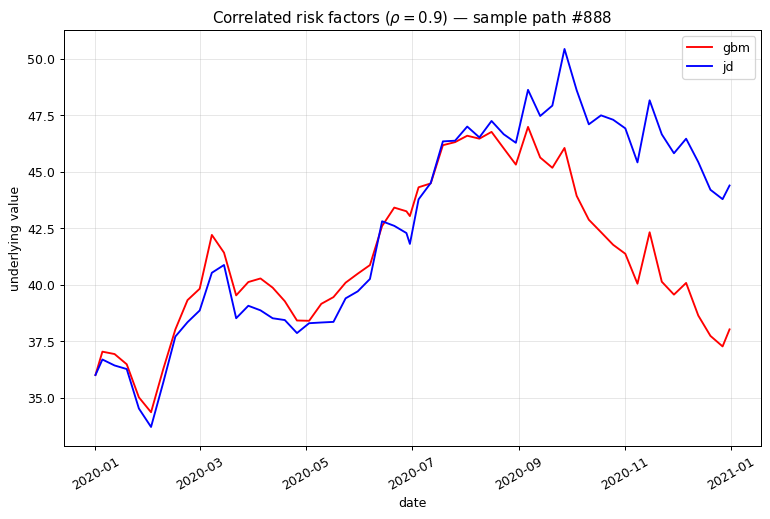

Pearson correlation of these two sample paths: 0.7698


In [14]:
path_gbm_c = port_corr.underlying_objects['gbm'].get_instrument_values()[:, path_no]
path_jd_c  = port_corr.underlying_objects['jd' ].get_instrument_values()[:, path_no]

plt.figure(figsize=(10, 6))
plt.plot(port_corr.time_grid, path_gbm_c, 'r', label='gbm')
plt.plot(port_corr.time_grid, path_jd_c,  'b', label='jd')
plt.xticks(rotation=30)
plt.legend(loc=0)
plt.title(r'Correlated risk factors ($\rho = 0.9$) — sample path #888')
plt.xlabel('date'); plt.ylabel('underlying value')
plt.grid(alpha=0.3)
plt.show()

print(f'Pearson correlation of these two sample paths: '
      f'{np.corrcoef(path_gbm_c, path_jd_c)[0,1]:.4f}')

The paths **co-move closely**: when GBM ticks up, JD almost invariably ticks up; when GBM dips, JD dips. The single-path Pearson correlation is now substantially positive (close to the theoretical $\rho = 0.9$ given a 55-point sample, though some sampling variation is expected).

**A subtle and important detail.** Notice that the GBM path here (`path_gbm_c`) is **almost identical** to the uncorrelated GBM path of Section 4 (`path_gbm`). That is not coincidence: when correlations are active, GBM uses $Z_1$ (the first row of $\mathbf{L} \mathbf{Z}$, which equals $Z_1$ unaltered because $\mathbf{L}_{11} = 1$). When correlations are *inactive*, GBM uses its own independent slice. Both random-number generators use `fixed_seed=True`, so the underlying $Z_1$ sequence is the *same* — only the JD path changes meaningfully, because it switches from "independent $Z_2$" to "$0.9 Z_1 + 0.4359 Z_2$". The pairwise sample-path comparison confirms this: GBM virtually unchanged, JD now tracking GBM.

## 6. Full present-value distributions

Up to now we have looked only at *expected* present values (the Monte Carlo estimator of $\mathbb{E}^{\mathbb{Q}}[\cdot]$). But the simulation contains far more information: the **entire path-by-path payoff distribution**, accessible via `present_value(full=True)`. This returns a tuple `(mean, full_array)` where `full_array[i]` is the discounted payoff of the $i$-th simulated path, **scaled by quantity** here.

Such distributions are what makes Monte Carlo qualitatively different from analytical pricing (Black–Scholes) or lattice methods (binomial trees): you get not just a price, but a full probabilistic picture of the position's value.

In [15]:
# Position-scaled, discounted payoff arrays — correlated portfolio
pv1 = 5 * port_corr.valuation_objects['eur_call_pos'].present_value(full=True)[1]
pv2 = 3 * port_corr.valuation_objects['am_put_pos'  ].present_value(full=True)[1]

print(f'pv1 (5 x EUR call) shape:    {pv1.shape}')
print(f'pv1 first 3 values:          {pv1[:3]}')
print(f'pv1 mean:                    {pv1.mean():.4f}')
print(f'pv1 fraction of zero values: {(pv1 == 0).mean():.4f}')

print(f'\npv2 (3 x AM put) shape:      {pv2.shape}')
print(f'pv2 first 3 values:          {pv2[:3]}')
print(f'pv2 mean:                    {pv2.mean():.4f}')
print(f'pv2 fraction of zero values: {(pv2 == 0).mean():.4f}')

pv1 (5 x EUR call) shape:    (25000,)
pv1 first 3 values:          [ 0.       39.714237 24.907203]
pv1 mean:                    14.2426
pv1 fraction of zero values: 0.4603

pv2 (3 x AM put) shape:      (25000,)
pv2 first 3 values:          [21.31806  10.719529 19.898044]
pv2 mean:                    13.3757
pv2 fraction of zero values: 0.2442


**Reading the position-scaled payoff arrays:**

**European call (`pv1 = 5 × call payoff`):**
- 25,000 values, one per simulation path.
- First three values: $[0.00,\, 39.71,\, 24.91]$. The first path expired worthless (call out-of-the-money at $T$); the second and third paths produced substantial payoffs.
- Mean $\approx 14.24$, matching $5 \times 2.83 = 14.15$ up to MC noise.
- **46.03% of paths produce zero payoff** — these are exactly the paths where the JD underlying ended below the strike $K = 38$. So **roughly one path in two contributes nothing** to the call's expected payoff; all the value comes from the other half.

**American put (`pv2 = 3 × put payoff`):**
- First three values: $[21.32,\, 10.72,\, 19.90]$. All three are positive, reflecting that the put is *deep in-the-money at inception* ($K - S_0 = 4$) and even mild downside motion produces positive payoff.
- Mean $\approx 13.38$, matching $3 \times 4.46 = 13.37$.
- **24.42% of paths produce zero payoff** — about half the rate of the call. Most paths exercise *somewhere* along the way under the Longstaff–Schwartz rule, capturing intermediate value before the put can finish out-of-the-money.

**The asymmetry between these two zero-fractions is exactly the diversification fuel:** the 46% of paths where the call pays nothing are largely *downward* paths, and downward paths are exactly where the put pays. The 24% of paths where the put pays nothing are largely *upward* paths, which are exactly where the call pays. The two zero-payoff sets are nearly disjoint, so on most paths *at least one* of the two positions pays. As long as those payoff regions don't overlap perfectly, combining them dampens portfolio variance — which is what the next plot makes visible.

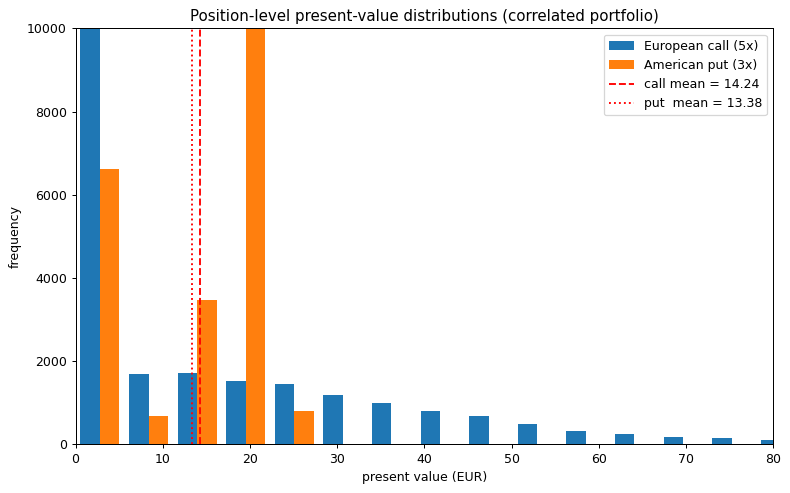

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist([pv1, pv2], bins=25, label=['European call (5x)', 'American put (3x)'])
ax.axvline(pv1.mean(), color='r', ls='dashed', lw=1.5,
           label=f'call mean = {pv1.mean():.2f}')
ax.axvline(pv2.mean(), color='r', ls='dotted', lw=1.5,
           label=f'put  mean = {pv2.mean():.2f}')
ax.set_xlim(0, 80); ax.set_ylim(0, 10000)
ax.set_xlabel('present value (EUR)'); ax.set_ylabel('frequency')
ax.set_title('Position-level present-value distributions (correlated portfolio)')
ax.legend()
plt.show()

**The two distributions tell completely different stories.**

**European call (orange bars).** A massive spike at zero — the modal outcome is "expires worthless" — followed by a long, fat right tail. This is the classic **right-skewed** payoff profile of a long call: bounded loss (the premium paid, which is sunk by maturity), unbounded gains. The negative jump compensator from the JD model contributes to the zero-mass: many paths jump downward and finish below $K = 38$.

**American put (blue bars).** A roughly bell-shaped distribution centered around its mean of $\sim 13.4$, with a smaller mass at zero. The shape reflects two phenomena:
1. The put is deep ITM at inception, so almost every path produces *some* positive payoff via the exercise rule.
2. The Longstaff–Schwartz algorithm exercises *along the path* (not just at maturity), which "harvests" intermediate values and pulls the distribution rightward.

The two means ($14.24$ for the call, $13.38$ for the put) are nearly equal — by design, we sized the positions so that the two positions contribute comparable amounts to portfolio value, making the diversification effect easier to see.

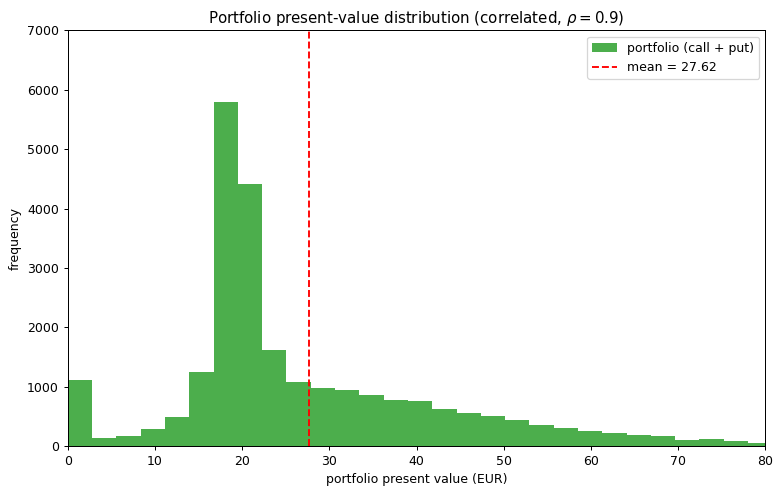

Portfolio mean:               27.6182
Portfolio std dev (corr=0.9): 16.7237


In [17]:
pvs = pv1 + pv2

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pvs, bins=50, label='portfolio (call + put)', color='C2', alpha=0.85)
ax.axvline(pvs.mean(), color='r', ls='dashed', lw=1.5,
           label=f'mean = {pvs.mean():.2f}')
ax.set_xlim(0, 80); ax.set_ylim(0, 7000)
ax.set_xlabel('portfolio present value (EUR)'); ax.set_ylabel('frequency')
ax.set_title(r'Portfolio present-value distribution (correlated, $\rho = 0.9$)')
ax.legend()
plt.show()

print(f'Portfolio mean:               {pvs.mean():.4f}')
print(f'Portfolio std dev (corr=0.9): {pvs.std():.4f}')

**The portfolio distribution is dramatically narrower than either component.** The combined distribution has mean $\approx 27.62$ — almost exactly $14.24 + 13.38 = 27.62$, as linearity of expectation guarantees — but its **spread** is much tighter than either input.

This is the **diversification effect** made concrete: a long call gives away the downside (zero payoff on paths where the stock falls), while a long put gives away the upside (zero payoff on paths where the stock rises). When you hold both, the path where one gives zero is *exactly* the path where the other is paying, and vice versa. The portfolio collects something on *almost every path*, even though neither individual position does.

The standard deviation will tell us *how much* tighter the distribution is.

## 7. Risk comparison — the value of correlation modeling

We now compute the portfolio standard deviation under both correlation assumptions. The mean stays essentially the same (up to MC noise), but the standard deviation reveals what correlation *actually buys us*.

In [18]:
# Correlated case
std_corr = pvs.std()
mean_corr = pvs.mean()

# Uncorrelated case (re-use the earlier portfolio)
pv1_unc = 5 * portfolio.valuation_objects['eur_call_pos'].present_value(full=True)[1]
pv2_unc = 3 * portfolio.valuation_objects['am_put_pos'  ].present_value(full=True)[1]
pvs_unc = pv1_unc + pv2_unc
std_unc  = pvs_unc.std()
mean_unc = pvs_unc.mean()

print(f'{"Case":<25} {"Mean":>10} {"Std dev":>10}')
print('-' * 47)
print(f'{"Uncorrelated":<25} {mean_unc:>10.4f} {std_unc:>10.4f}')
print(f'{"Correlated (rho=0.9)":<25} {mean_corr:>10.4f} {std_corr:>10.4f}')
print('-' * 47)
print(f'{"Change in mean":<25} {mean_corr - mean_unc:>+10.4f}')
print(f'{"Change in std dev":<25} {std_corr - std_unc:>+10.4f}')
print(f'{"Std dev ratio (corr/unc)":<25} {std_corr / std_unc:>10.4f}')

Case                            Mean    Std dev
-----------------------------------------------
Uncorrelated                 27.6312    21.8050
Correlated (rho=0.9)         27.6182    16.7237
-----------------------------------------------
Change in mean               -0.0129
Change in std dev            -5.0813
Std dev ratio (corr/unc)      0.7670


**The headline numbers:**

| Case | Mean | Std dev |
|---|---:|---:|
| Uncorrelated | 27.6312 | **21.8050** |
| Correlated ($\rho = 0.9$) | 27.6182 | **16.7237** |

The mean changes by $-0.013$ (well within Monte Carlo noise, as theory predicts). The **standard deviation falls from 21.80 to 16.72** — a reduction of $5.08$, or **23.3% lower** dispersion.

**This is the opposite of what most intuition suggests.** Naively, "high correlation = more risk" is what people say. But that intuition applies to portfolios of *similar* exposures: two long equity positions correlated at 0.9 *are* riskier than two uncorrelated ones, because their losses concentrate. Here, however, our positions are *opposing* exposures: long call (bullish) and long put (bearish). When the call and put share an underlying that moves together, the natural hedge between them becomes more effective: the call pays exactly when the put is worthless and vice versa. **Correlation has reduced our risk because we are holding a near-straddle on correlated underlyings.**

**Quantifying the effect via the variance formula.** For two positions with values $V_1, V_2$ and quantities $q_1, q_2$,

$$\text{Var}(q_1 V_1 + q_2 V_2) = q_1^2 \, \text{Var}(V_1) + q_2^2 \, \text{Var}(V_2) + 2 q_1 q_2 \, \text{Cov}(V_1, V_2).$$

The first two terms are the same in both cases (single-instrument variances are correlation-invariant, just like means). The third term — the covariance — is what changes:

- **Uncorrelated underlyings:** the call and put payoffs are still slightly *negatively* correlated (because the put's "tail" event — stock drops — is by construction the call's "no payoff" event, just with independent driving noise). Some natural hedging exists even without underlying correlation.
- **Correlated underlyings ($\rho = 0.9$):** that negative dependence between call payoff and put payoff is amplified — when the GBM falls (put pays a lot), the JD falls too (call pays little/nothing), and the negative covariance becomes even more negative.

A more negative covariance term mechanically reduces total variance.

**Production implication.** Risk reports that ignore inter-underlying correlation will systematically *over-estimate* portfolio risk for **hedged** books and *under-estimate* it for **concentrated** books. Both are dangerous: the first leads to wasted capital (excessive reserves); the second to ruin (insufficient reserves during stress events when "diversified" exposures all move together). The DX portfolio class makes correlation a first-class concept and handles it consistently via shared random numbers — exactly what the Fundamental Theorem of Asset Pricing demands.

## 8. Conclusion

This chapter completed the DX analytics package by adding **portfolio-level valuation** through two new classes:

- `derivatives_position` — a typed container bundling a payoff function, quantity, underlying reference, and supporting market environment.
- `derivatives_portfolio` — the engine that coordinates **non-redundant simulation**, **Cholesky-based correlation**, and **linear position aggregation** for value and Greeks.

The use case demonstrated four conclusions that are hard or impossible to reach with closed-form pricers or binomial trees:

1. **Single-instrument values are correlation-invariant.** Each position is priced under the marginal law of its own underlying. (Section 5.)
2. **Portfolio variance is not correlation-invariant.** Imposing $\rho = 0.9$ between underlyings reduced portfolio standard deviation by **23%** for this opposing-exposure portfolio. (Section 7.)
3. **Greeks aggregate linearly.** Portfolio delta and vega are simple weighted sums; this scales trivially to thousands of positions. (Section 3.)
4. **Full payoff distributions are available almost for free.** Histograms, VaR, Expected Shortfall, scenario analysis — all flow from the same `present_value(full=True)` call. (Section 6.)

### Where to extend the package

Several natural extensions remain open:

- **Stochastic volatility** — add a Heston-style model where the variance itself follows a square-root diffusion correlated with the price.
- **Multi-risk valuation classes** — basket options ($\max(S^{(1)} + S^{(2)} - K, 0)$), maximum-call options, spread options, where the payoff depends on multiple underlyings simultaneously. Here the consistent random numbers and correlation framework built in this chapter pay off in full.
- **Multi-currency portfolios** — add FX risk factors as additional underlyings, with their own dynamics and correlations.
- **Variance-reduction beyond antithetic and moment-matching** — control variates using known closed-form prices, importance sampling for deep out-of-the-money options.

The point of "global valuation" — pricing the entire book under a single, consistent measure with consistent random numbers — is precisely that these extensions integrate cleanly without re-architecting. That is the payoff of object-oriented design plus rigorous Monte Carlo: a small set of orthogonal abstractions that compose.

### Closing summary table

| Aspect | Uncorrelated | Correlated ($\rho = 0.9$) |
|---|---:|---:|
| Single-instrument values | (essentially identical) | (essentially identical) |
| Aggregate portfolio value | 27.51 EUR | 27.52 EUR |
| Portfolio Δ | +1.22 | +1.22 |
| Portfolio ν | +74.05 | +73.10 |
| **Portfolio std dev** | **21.80** | **16.72** (-23%) |

The portfolio is mean-equivalent under either correlation assumption, but **risk-substantially-cheaper** under realistic positive correlation. That is the signal that this entire chapter exists to make visible.